# **Figures:**

This notebook consists of the following steps:

1. Master setup cell

2. Figure 1 scatter plot cell

3. Figure 2 histogram cell

4. Figure 3 box plots cell

5. Figure 4 correlation heatmap cell

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All liberaries are loaded successfully")


All liberaries are loaded successfully


In [39]:
df = pd.read_excel("/content/ML targets (7).xlsx")
print('Shape of the dataset:', df.shape)
print('\nLabel counts:')
print(df['RMSD_Mimic_Target (Y)'].value_counts())
print('\nColumn Name:')
print(df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0])


Shape of the dataset: (399, 23)

Label counts:
RMSD_Mimic_Target (Y)
Y    262
N    137
Name: count, dtype: int64

Column Name:
['Organism', 'Protein', 'Position', 'HLA Haplotype', 'Pathogen Peptide', 'pathogen length', '%Rank_EL(X)', 'Aff(nM)(X)', 'Immunogenicity', 'Type of MHC', 'Human_match', 'BLOSUM80 score', 'Identity percentage', 'Alignment length (Sequence)', 'Identical aa', 'Positions', 'Human Peptide', 'Human length', 'Alignment Length (Structure)', 'Structural RMSD', 'TM-align score (Human chain 2)', 'Structural alignment coverage %', 'RMSD_Mimic_Target (Y)']

Missing values:
Series([], dtype: int64)


In [40]:
df['BLOSUM80 score'] = pd.to_numeric(df['BLOSUM80 score'], errors='coerce')
df['pathogen length'] = pd.to_numeric(df['pathogen length'], errors='coerce')
df['Alignment length (Sequence)'] = pd.to_numeric(df['Alignment length (Sequence)'], errors='coerce')
df['BLOSUM80_per_residue'] = df['BLOSUM80 score'] / df['Alignment length (Sequence)']

df['Alignment_coverage_sequence'] = (df['Alignment length (Sequence)'] / df['pathogen length'] * 100).clip(upper=100)

print("New shape:", df.shape)  # Should now say (399, 25)
print("\nNew columns confirmed:")
print(df[['BLOSUM80_per_residue', 'Alignment_coverage_sequence']].head())


New shape: (399, 25)

New columns confirmed:
   BLOSUM80_per_residue  Alignment_coverage_sequence
0                   NaN                          NaN
1              4.111111                         90.0
2              2.916667                        100.0
3              4.000000                         90.0
4              4.375000                         80.0


In [41]:
columns_to_convert = [
    'BLOSUM80 score',
    'Identity percentage',
    'Alignment length (Sequence)',
    'Identical aa',
    'pathogen length',
    'Human length',
    '%Rank_EL(X)',
    'Aff(nM)(X)',
    'Structural RMSD',
    'TM-align score (Human chain 2)',
    'Structural alignment coverage %',
    'Alignment Length (Structure)'
]

for col in columns_to_convert:
  df[col] = pd.to_numeric(df[col], errors='coerce')

df['BLOSUM80_per_residue'] = df['BLOSUM80 score'] / df['Alignment length (Sequence)']
df['Alignment_coverage_sequence'] = (df['Alignment length (Sequence)'] / df['pathogen length'] * 100).clip(upper=100)
print('All Columns Converted Successfully!')
print('\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum()>0])

Y_group = df[df['RMSD_Mimic_Target (Y)'] == 'Y']
N_group = df[df['RMSD_Mimic_Target (Y)'] == 'N']

print(f'Y Group_size : {len(Y_group)}')
print(f'N Group_size : {len(N_group)}')



All Columns Converted Successfully!

Missing values per column:
BLOSUM80 score                    127
Identity percentage               127
Alignment length (Sequence)       128
Identical aa                      127
TM-align score (Human chain 2)      1
BLOSUM80_per_residue              128
Alignment_coverage_sequence       128
dtype: int64
Y Group_size : 262
N Group_size : 137


# **Figures:**

**Figure1**

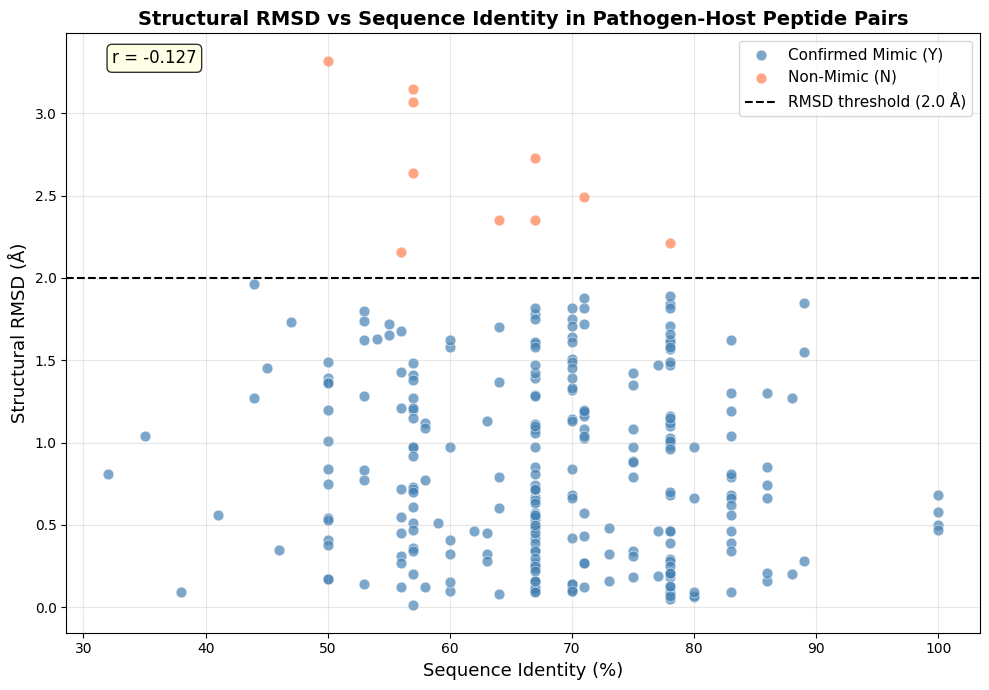

Correlation coefficient (r): -0.127
Figure saved as figure1_rmsd_vs_identity.png
Figure1 done YAYAYAA


In [42]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(10, 7))

plt.scatter(
    Y_group['Identity percentage'],
    Y_group['Structural RMSD'],
    color='steelblue',
    alpha=0.7,
    label = 'Confirmed Mimic (Y)',
    edgecolors='white',
    linewidths = 0.5,
    s = 60
)

plt.scatter(
    N_group['Identity percentage'],
    N_group['Structural RMSD'],
    color='coral',
    alpha=0.7,
    label = 'Non-Mimic (N)',
    edgecolors='white',
    linewidths = 0.5,
    s = 60
)


plt.axhline(y=2.0, color='Black', linestyle='--', linewidth=1.5,
            label='RMSD threshold (2.0 Å)')

plt.xlabel('Sequence Identity (%)', fontsize=13)
plt.ylabel('Structural RMSD (Å)', fontsize=13)
plt.title('Structural RMSD vs Sequence Identity in Pathogen-Host Peptide Pairs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

correlation =df['Identity percentage'].corr(df['Structural RMSD'])
plt.annotate(f'r = {correlation:.3f}',
             xy=(0.05, 0.95),
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('figure1_rmsd_vs_identity.png', dpi=300, bbox_inches = 'tight')

plt.show()
print(f'Correlation coefficient (r): {correlation:.3f}')
print('Figure saved as figure1_rmsd_vs_identity.png')
print('Figure1 done YAYAYAA')




The blue points — 262 confirmed mimics — are scattered across the entire range of sequence identity from 30% to 100%, all clustered below the 2.0 Å threshold line.

There is no diagonal pattern whatsoever. High sequence identity does not push points lower on the RMSD axis.

The coral/orange points — 137 non-mimics — sit above the threshold line, also scattered across a wide range of sequence identity.

Some non-mimics have sequence identity as high as 80-90% and still failed structural validation.

# The r = -0.127 in the top left corner is the quantitative summary of what we can see visually — essentially no relationship between sequence similarity and structural similarity.

However, I was not exactly happy about the intense overlap between points in the non-mimics, leading me to then include jitter to improve visualization.

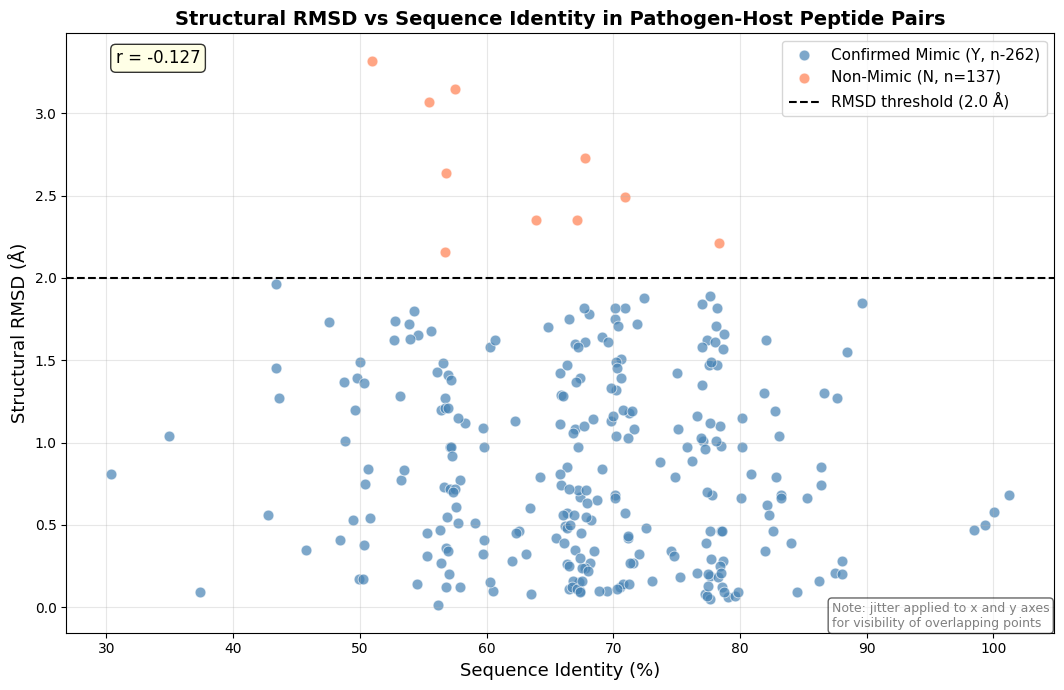

Figure 1 final version saved


In [43]:
np.random.seed(42)

Y_jitter_x = Y_group['Identity percentage']+ np.random.normal(0,0.8,len(Y_group))
N_jitter_x = N_group['Identity percentage']+ np.random.normal(0,0.8,len(N_group))

Y_jitter_y = Y_group['Structural RMSD'] + np.random.normal(0, 0.01, len(Y_group))
N_jitter_y = N_group['Structural RMSD'] + np.random.normal(0, 0.01, len(N_group))

plt.figure(figsize=(11, 7))

plt.scatter(
    Y_jitter_x,
    Y_group['Structural RMSD'],
    color='steelblue',
    alpha=0.7,
    label = 'Confirmed Mimic (Y, n-262)',
    edgecolors='white',
    linewidths = 0.6,
    s = 60
)

plt.scatter(
    N_jitter_x,
    N_group['Structural RMSD'],
    color='coral',
    alpha=0.7,
    label = 'Non-Mimic (N, n=137)',
    edgecolors='white',
    linewidths = 0.6,
    s = 60
)


plt.axhline(y=2.0, color='Black', linestyle='--', linewidth=1.5,
            label='RMSD threshold (2.0 Å)')

plt.xlabel('Sequence Identity (%)', fontsize=13)
plt.ylabel('Structural RMSD (Å)', fontsize=13)
plt.title('Structural RMSD vs Sequence Identity in Pathogen-Host Peptide Pairs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

correlation =df['Identity percentage'].corr(df['Structural RMSD'])
plt.annotate(f'r = {correlation:.3f}',
             xy=(0.05, 0.95),
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.annotate('Note: jitter applied to x and y axes\nfor visibility of overlapping points',
             xy=(0.775, 0.01),
             xycoords='axes fraction',
             fontsize=9,
             color='gray',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))

plt.tight_layout()
plt.savefig('figure1_rmsd_vs_identity.png', dpi=300, bbox_inches = 'tight')

plt.show()
print('Figure 1 final version saved')

This is the final figure we decided to go with.

**Figure2**

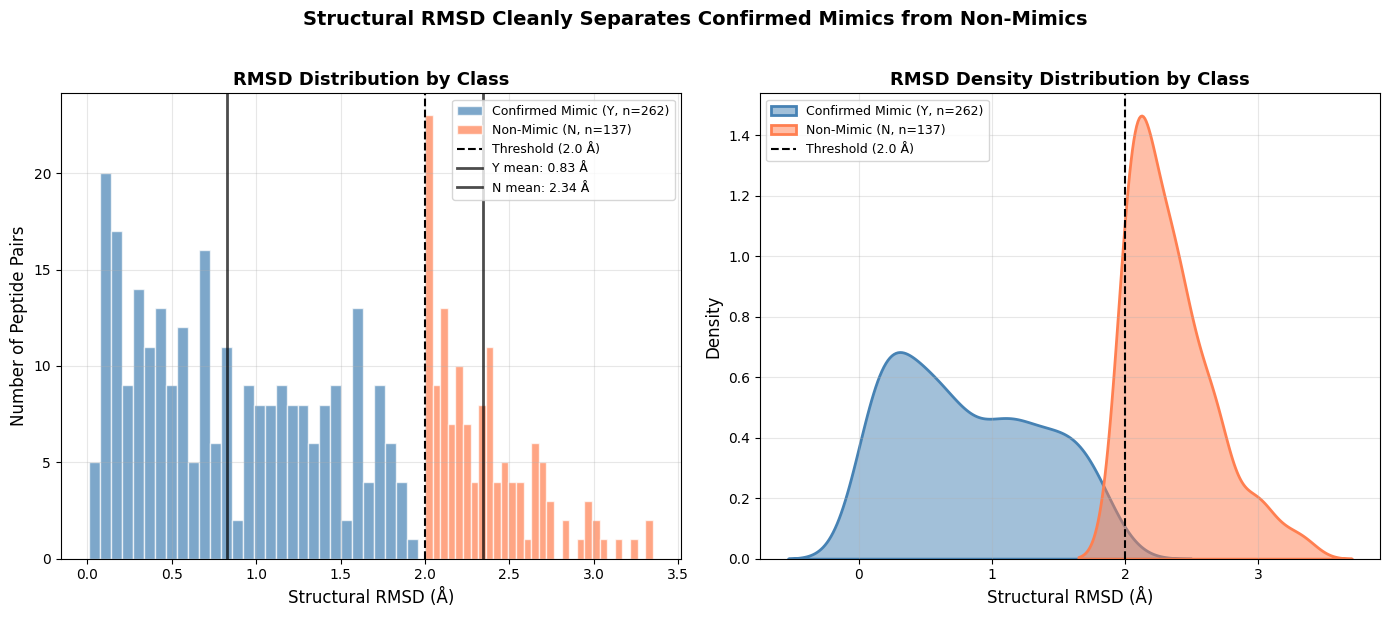

Summary statistics:
Y group — Mean RMSD: 0.825 Å, Std: 0.546 Å, Range: 0.010–1.960 Å
N group — Mean RMSD: 2.344 Å, Std: 0.313 Å, Range: 2.000–3.350 Å


In [44]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].hist(
    Y_group['Structural RMSD'].dropna(),
    bins=30,
    color='steelblue',
    alpha=0.7,
    label=f'Confirmed Mimic (Y, n=262)',
    edgecolor='white'
)
axes[0].hist(
    N_group['Structural RMSD'].dropna(),
    bins=30,
    color='coral',
    alpha=0.7,
    label=f'Non-Mimic (N, n=137)',
    edgecolor='white'
)

axes[0].axvline(x=2.0, color='black', linestyle='--',
                linewidth=1.5, label='Threshold (2.0 Å)')

axes[0].axvline(
    x=Y_group['Structural RMSD'].mean(),
    color='black', linestyle='-',
    linewidth=2, alpha=0.7,
    label=f"Y mean: {Y_group['Structural RMSD'].mean():.2f} Å"
)
axes[0].axvline(
    x=N_group['Structural RMSD'].mean(),
    color='black', linestyle='-',
    linewidth=2, alpha=0.7,
    label=f"N mean: {N_group['Structural RMSD'].mean():.2f} Å"
)

axes[0].set_xlabel('Structural RMSD (Å)', fontsize=12)
axes[0].set_ylabel('Number of Peptide Pairs', fontsize=12)
axes[0].set_title('RMSD Distribution by Class', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)


sns.kdeplot(
    data=Y_group['Structural RMSD'].dropna(),
    ax=axes[1],
    color='steelblue',
    fill=True,
    alpha=0.5,
    linewidth=2,
    label=f'Confirmed Mimic (Y, n=262)'
)
sns.kdeplot(
    data=N_group['Structural RMSD'].dropna(),
    ax=axes[1],
    color='coral',
    fill=True,
    alpha=0.5,
    linewidth=2,
    label=f'Non-Mimic (N, n=137)'
)

axes[1].axvline(x=2.0, color='black', linestyle='--',
                linewidth=1.5, label='Threshold (2.0 Å)')
axes[1].set_xlabel('Structural RMSD (Å)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('RMSD Density Distribution by Class',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Structural RMSD Cleanly Separates Confirmed Mimics from Non-Mimics',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('figure2_rmsd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


print("Summary statistics:")
print(f"Y group — Mean RMSD: {Y_group['Structural RMSD'].mean():.3f} Å, "
      f"Std: {Y_group['Structural RMSD'].std():.3f} Å, "
      f"Range: {Y_group['Structural RMSD'].min():.3f}–{Y_group['Structural RMSD'].max():.3f} Å")
print(f"N group — Mean RMSD: {N_group['Structural RMSD'].mean():.3f} Å, "
      f"Std: {N_group['Structural RMSD'].std():.3f} Å, "
      f"Range: {N_group['Structural RMSD'].min():.3f}–{N_group['Structural RMSD'].max():.3f} Å")

The blue bars are almost entirely to the left of the 2.0 Å threshold line with only one blue bar crossing it — that is the single blue outlier we noted earlier. The coral bars start right at the threshold and spread rightward. The two mean lines signalled by the black line at 0.83 Å and at 2.34 Å are well separated.

The blue curve on the right peaks around 0.3 Å and falls off before reaching 2.0 Å. The coral curve peaks sharply just above 2.0 Å and spreads rightward. The tiny overlap region right at the threshold is biologically meaningful — it shows your 2.0 Å cutoff is conservative and honest, not arbitrary. A reviewer seeing this cannot question your threshold choice.

However, the density plot extends slightly into negative RMSD values on the left — the blue curve can be seen touching below zero. RMSD cannot be negative in reality, this is just a mathematical smoothing artefact of the density estimation.

**Mentioning this briefly — "density curves extend to negative values due to kernel smoothing artefact — RMSD values are strictly non-negative".**

In [45]:
# ── Re-establish all statistical variables needed for figures ──────────────
from scipy import stats
import numpy as np

# Recreate Y and N groups
Y_group = df[df['RMSD_Mimic_Target (Y)'] == 'Y']
N_group = df[df['RMSD_Mimic_Target (Y)'] == 'N']

# Mann-Whitney U tests
stat_blosum, p_blosum = stats.mannwhitneyu(
    Y_group['BLOSUM80 score'].dropna(),
    N_group['BLOSUM80 score'].dropna(),
    alternative='two-sided'
)

stat_identity, p_identity = stats.mannwhitneyu(
    Y_group['Identity percentage'].dropna(),
    N_group['Identity percentage'].dropna(),
    alternative='two-sided'
)

stat_coverage, p_coverage = stats.mannwhitneyu(
    Y_group['Alignment_coverage_sequence'].dropna(),
    N_group['Alignment_coverage_sequence'].dropna(),
    alternative='two-sided'
)

# Cohen's d function
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return diff / pooled_std

d_blosum   = cohens_d(Y_group['BLOSUM80 score'].dropna(),
                      N_group['BLOSUM80 score'].dropna())
d_identity = cohens_d(Y_group['Identity percentage'].dropna(),
                      N_group['Identity percentage'].dropna())
d_coverage = cohens_d(Y_group['Alignment_coverage_sequence'].dropna(),
                      N_group['Alignment_coverage_sequence'].dropna())

print("All variables ready:")
print(f"p_blosum={p_blosum:.4f}, p_identity={p_identity:.4f}, p_coverage={p_coverage:.4f}")
print(f"d_blosum={d_blosum:.3f}, d_identity={d_identity:.3f}, d_coverage={d_coverage:.3f}")

All variables ready:
p_blosum=0.1934, p_identity=0.0819, p_coverage=0.1024
d_blosum=-0.470, d_identity=0.560, d_coverage=-0.850


/tmp/ipykernel_3106/1710734500.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
/tmp/ipykernel_3106/1710734500.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
/tmp/ipykernel_3106/1710734500.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])


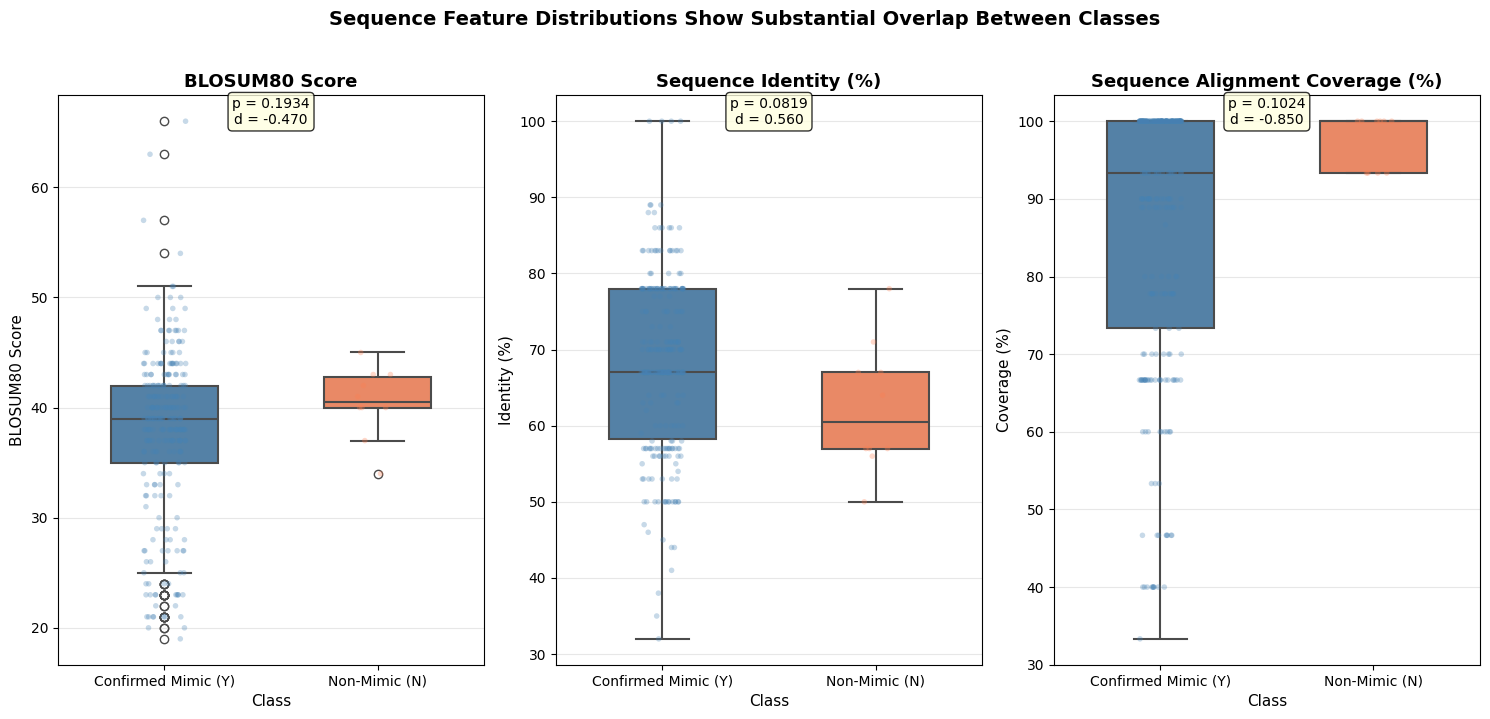

Figure saved — no FutureWarnings.


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# --- BLOSUM80 ---
sns.boxplot(
    data=df.dropna(subset=['BLOSUM80 score']),
    x='RMSD_Mimic_Target (Y)', y='BLOSUM80 score',
    hue='RMSD_Mimic_Target (Y)',
    palette={'Y': 'steelblue', 'N': 'coral'},
    width=0.5, linewidth=1.5, legend=False, ax=axes[0]
)
sns.stripplot(
    data=df.dropna(subset=['BLOSUM80 score']),
    x='RMSD_Mimic_Target (Y)', y='BLOSUM80 score',
    hue='RMSD_Mimic_Target (Y)',
    palette={'Y': 'steelblue', 'N': 'coral'},
    alpha=0.3, size=4, jitter=True, legend=False, ax=axes[0]
)
axes[0].set_title('BLOSUM80 Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('BLOSUM80 Score', fontsize=11)
axes[0].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
axes[0].annotate(f'p = {p_blosum:.4f}\nd = {d_blosum:.3f}',
                 xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[0].grid(True, alpha=0.3, axis='y')

# --- Identity % ---
sns.boxplot(
    data=df.dropna(subset=['Identity percentage']),
    x='RMSD_Mimic_Target (Y)', y='Identity percentage',
    hue='RMSD_Mimic_Target (Y)',
    palette={'Y': 'steelblue', 'N': 'coral'},
    width=0.5, linewidth=1.5, legend=False, ax=axes[1]
)
sns.stripplot(
    data=df.dropna(subset=['Identity percentage']),
    x='RMSD_Mimic_Target (Y)', y='Identity percentage',
    hue='RMSD_Mimic_Target (Y)',
    palette={'Y': 'steelblue', 'N': 'coral'},
    alpha=0.3, size=4, jitter=True, legend=False, ax=axes[1]
)
axes[1].set_title('Sequence Identity (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Identity (%)', fontsize=11)
axes[1].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
axes[1].annotate(f'p = {p_identity:.4f}\nd = {d_identity:.3f}',
                 xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].grid(True, alpha=0.3, axis='y')

# --- Alignment Coverage ---
sns.boxplot(
    data=df.dropna(subset=['Alignment_coverage_sequence']),
    x='RMSD_Mimic_Target (Y)', y='Alignment_coverage_sequence',
    hue='RMSD_Mimic_Target (Y)',
    palette={'Y': 'steelblue', 'N': 'coral'},
    width=0.5, linewidth=1.5, legend=False, ax=axes[2]
)
sns.stripplot(
    data=df.dropna(subset=['Alignment_coverage_sequence']),
    x='RMSD_Mimic_Target (Y)', y='Alignment_coverage_sequence',
    hue='RMSD_Mimic_Target (Y)',
    palette={'Y': 'steelblue', 'N': 'coral'},
    alpha=0.3, size=4, jitter=True, legend=False, ax=axes[2]
)
axes[2].set_title('Sequence Alignment Coverage (%)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Class', fontsize=11)
axes[2].set_ylabel('Coverage (%)', fontsize=11)
axes[2].set_xticklabels(['Confirmed Mimic (Y)', 'Non-Mimic (N)'])
axes[2].annotate(f'p = {p_coverage:.4f}\nd = {d_coverage:.3f}',
                 xy=(0.5, 0.95), xycoords='axes fraction', ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].grid(True, alpha=0.3, axis='y')

fig.suptitle('Sequence Feature Distributions Show Substantial Overlap Between Classes',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure_boxplots_sequence_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved — no FutureWarnings.")

**Left — BLOSUM80 Score:**

The two boxes heavily overlap — Y median around 39, N median around 41. The Y group has many outliers stretching upward which is why the distribution is wider. p = 0.1934, not significant. The classes are statistically indistinguishable on BLOSUM score.

**Middle — Sequence Identity:**

Again substantial overlap between the two boxes. Y median around 68%, N median around 61%. The Y group spreads wider — from 30% all the way to 100% — while N is more compressed between 55-78%. p = 0.0819, not significant. Despite a visible median difference the distributions overlap too much to be reliable classifiers.

**Right — Alignment Coverage:**

This is the most visually striking panel. The Y group box is enormous — spanning from about 35% to 100% with huge variance. The N group box sits tightly clustered near 100% with almost no spread. This is the large Cohen's d of -0.850 showing visually. The negatives have near-complete alignment coverage while the positives are far more variable. p = 0.1024, not significant despite the visual difference.


The N group in the coverage plot has almost no whiskers or outliers — it is a very tight box sitting near 100%. This visually confirms what we discussed about the negative sampling strategy producing a homogeneous group.

In [47]:
# ── ADDITION: Test statistical significance of the key correlation ──────────
# r = -0.127 with n=399 is likely significant even though it is small
# We must report this honestly or reviewers will flag it

from scipy.stats import pearsonr

# Drop rows where either value is missing before testing
valid_pairs = df[['Identity percentage', 'Structural RMSD']].dropna()
r_val, p_val = pearsonr(valid_pairs['Identity percentage'],
                         valid_pairs['Structural RMSD'])

r_sq = r_val**2  # variance explained

print("=== Pearson Correlation: Identity % vs Structural RMSD ===")
print(f"n = {len(valid_pairs)}")
print(f"r = {r_val:.4f}")
print(f"p = {p_val:.4f}")
print(f"R² = {r_sq:.4f}  ({r_sq*100:.2f}% of variance in RMSD explained by sequence identity)")
print()
if p_val < 0.05:
    print("RESULT: Statistically significant but PRACTICALLY NEGLIGIBLE relationship.")
    print("Correct paper framing: 'a statistically significant but negligible correlation")
    print(f"(r = {r_val:.3f}, p = {p_val:.3f}), with sequence identity explaining only")
    print(f"{r_sq*100:.1f}% of variance in structural RMSD'")
else:
    print("RESULT: Not statistically significant.")

=== Pearson Correlation: Identity % vs Structural RMSD ===
n = 272
r = -0.1272
p = 0.0360
R² = 0.0162  (1.62% of variance in RMSD explained by sequence identity)

RESULT: Statistically significant but PRACTICALLY NEGLIGIBLE relationship.
Correct paper framing: 'a statistically significant but negligible correlation
(r = -0.127, p = 0.036), with sequence identity explaining only
1.6% of variance in structural RMSD'


In [48]:
# ── ADDITION: Bonferroni correction table ───────────────────────────────────
# We ran 3 Mann-Whitney tests. Standard practice is to apply correction.
# Bonferroni threshold = 0.05 / 3 = 0.0167

alpha = 0.05
n_tests = 3
bonferroni_threshold = alpha / n_tests

results = {
    'Feature': ['BLOSUM80 Score', 'Identity Percentage (%)', 'Alignment Coverage (%)'],
    'U Statistic': [992.50, 1732.50, 933.00],
    'p-value': [p_blosum, p_identity, p_coverage],
    'Bonferroni threshold': [bonferroni_threshold] * 3,
    'Significant (corrected)?': [
        p_blosum < bonferroni_threshold,
        p_identity < bonferroni_threshold,
        p_coverage < bonferroni_threshold
    ]
}

results_df = pd.DataFrame(results)
print("=== Mann-Whitney U Tests with Bonferroni Correction ===")
print(f"Bonferroni threshold: α / n_tests = {alpha} / {n_tests} = {bonferroni_threshold:.4f}")
print()
print(results_df.to_string(index=False))
print()
print("All three features remain non-significant after Bonferroni correction.")
print("This strengthens rather than weakens the central finding.")

=== Mann-Whitney U Tests with Bonferroni Correction ===
Bonferroni threshold: α / n_tests = 0.05 / 3 = 0.0167

                Feature  U Statistic  p-value  Bonferroni threshold  Significant (corrected)?
         BLOSUM80 Score        992.5 0.193364              0.016667                     False
Identity Percentage (%)       1732.5 0.081882              0.016667                     False
 Alignment Coverage (%)        933.0 0.102430              0.016667                     False

All three features remain non-significant after Bonferroni correction.
This strengthens rather than weakens the central finding.


**Figure4**

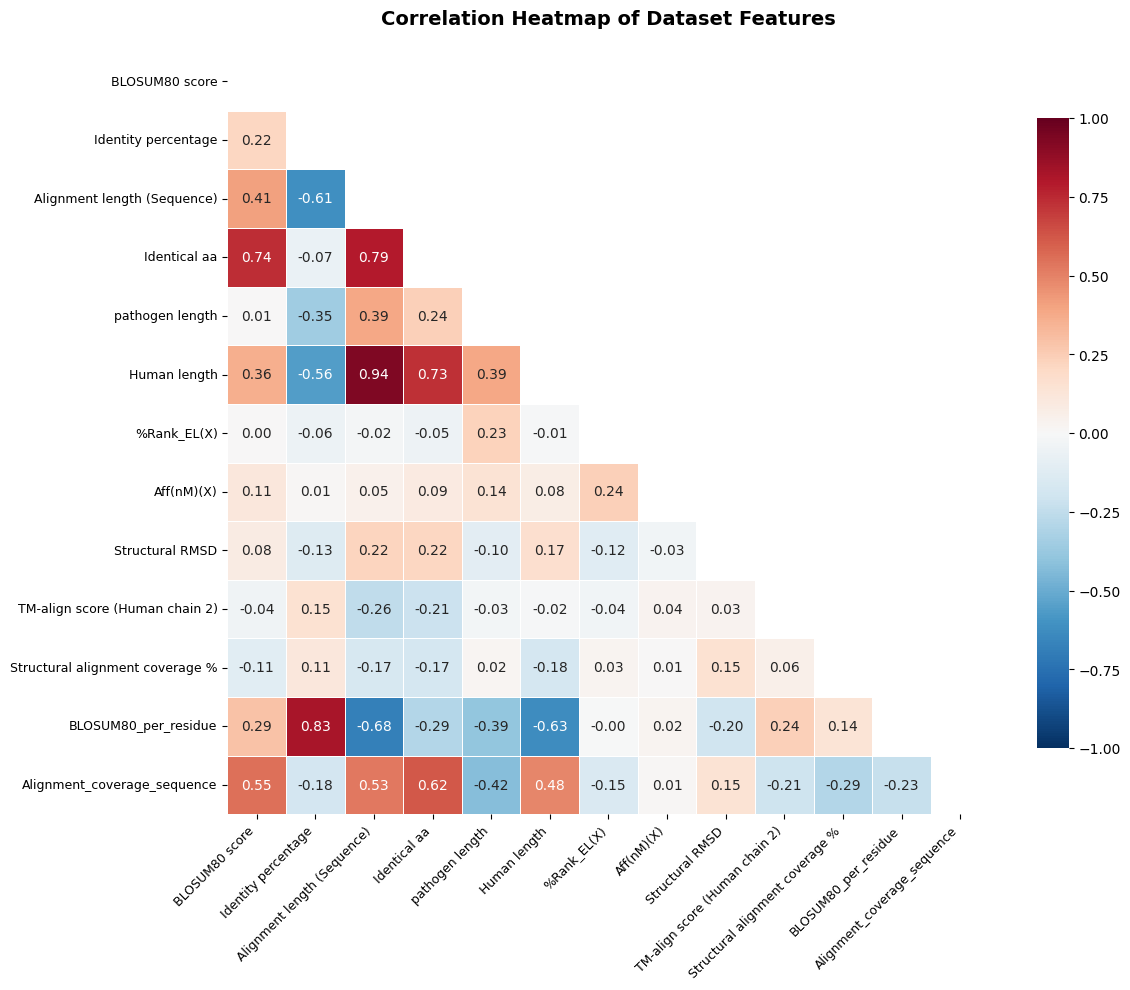

Key correlations for your results section:
Identity % vs Structural RMSD:-0.127
BLOSUM80 score vs TM-align score: -0.039
Identity % vs BLOSUM80 score: 0.218


In [49]:
feature_cols = [
    'BLOSUM80 score',
    'Identity percentage',
    'Alignment length (Sequence)',
    'Identical aa',
    'pathogen length',
    'Human length',
    '%Rank_EL(X)',
    'Aff(nM)(X)',
    'Structural RMSD',
    'TM-align score (Human chain 2)',
    'Structural alignment coverage %',
    'BLOSUM80_per_residue',
    'Alignment_coverage_sequence'
]

corr_matrix = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap of Dataset Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('figure4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Key correlations for your results section:')
print(f'Identity % vs Structural RMSD:'
      f'{corr_matrix.loc['Identity percentage', 'Structural RMSD']:.3f}')
print(f'BLOSUM80 score vs TM-align score: '
      f'{corr_matrix.loc['BLOSUM80 score', 'TM-align score (Human chain 2)']:.3f}')
print(f'Identity % vs BLOSUM80 score: '
      f'{corr_matrix.loc['Identity percentage', 'BLOSUM80 score']:.3f}')

**Identity % vs Structural RMSD:** -0.127

This is near zero. This is the central finding confirmed again in the heatmap — the pale pink cell where Identity percentage row meets Structural RMSD column. Sequence similarity does not predict structural similarity.

**BLOSUM80 vs TM-align score:** -0.039

This is essentially zero. The sequence substitution score has no relationship with the structural alignment score whatsoever.

**Identity % vs BLOSUM80:** 0.218

This is a weak positive which makes biological sense since more identical residues tend to give better BLOSUM scores. This is not surprising and not concerning.


**Other interesting patterns in the heatmap:**

1. **The dark red cell** — Identical aa vs Human length: **0.94**. Very strong positive correlation, which makes perfect sense — longer peptides naturally have more identical amino acids in absolute terms. This is not scientifically meaningful, just a mathematical consequence of peptide length.

2. **BLOSUM80_per_residue vs Alignment length: -0.68**. Strong negative — longer alignments tend to have lower per-residue BLOSUM scores. Again biologically logical.

3. **Structural RMSD row** — Every single value is close to zero or very small. This visually confirms that RMSD has essentially no linear relationship with any sequence feature. That entire row being pale and washed out is the finding displayed in matrix form.

In [50]:
# ── ADDITION: Test statistical significance of the key correlation ──────────
# r = -0.127 with n=399 is likely significant even though it is small
# We must report this honestly or reviewers will flag it

from scipy.stats import pearsonr

# Drop rows where either value is missing before testing
valid_pairs = df[['Identity percentage', 'Structural RMSD']].dropna()
r_val, p_val = pearsonr(valid_pairs['Identity percentage'],
                         valid_pairs['Structural RMSD'])

r_sq = r_val**2  # variance explained

print("=== Pearson Correlation: Identity % vs Structural RMSD ===")
print(f"n = {len(valid_pairs)}")
print(f"r = {r_val:.4f}")
print(f"p = {p_val:.4f}")
print(f"R² = {r_sq:.4f}  ({r_sq*100:.2f}% of variance in RMSD explained by sequence identity)")
print()
if p_val < 0.05:
    print("RESULT: Statistically significant but PRACTICALLY NEGLIGIBLE relationship.")
    print("Correct paper framing: 'a statistically significant but negligible correlation")
    print(f"(r = {r_val:.3f}, p = {p_val:.3f}), with sequence identity explaining only")
    print(f"{r_sq*100:.1f}% of variance in structural RMSD'")
else:
    print("RESULT: Not statistically significant.")

=== Pearson Correlation: Identity % vs Structural RMSD ===
n = 272
r = -0.1272
p = 0.0360
R² = 0.0162  (1.62% of variance in RMSD explained by sequence identity)

RESULT: Statistically significant but PRACTICALLY NEGLIGIBLE relationship.
Correct paper framing: 'a statistically significant but negligible correlation
(r = -0.127, p = 0.036), with sequence identity explaining only
1.6% of variance in structural RMSD'


In [51]:
# ── ADDITION: Bonferroni correction table ───────────────────────────────────
# We ran 3 Mann-Whitney tests. Standard practice is to apply correction.
# Bonferroni threshold = 0.05 / 3 = 0.0167

alpha = 0.05
n_tests = 3
bonferroni_threshold = alpha / n_tests

results = {
    'Feature': ['BLOSUM80 Score', 'Identity Percentage (%)', 'Alignment Coverage (%)'],
    'U Statistic': [992.50, 1732.50, 933.00],
    'p-value': [p_blosum, p_identity, p_coverage],
    'Bonferroni threshold': [bonferroni_threshold] * 3,
    'Significant (corrected)?': [
        p_blosum < bonferroni_threshold,
        p_identity < bonferroni_threshold,
        p_coverage < bonferroni_threshold
    ]
}

results_df = pd.DataFrame(results)
print("=== Mann-Whitney U Tests with Bonferroni Correction ===")
print(f"Bonferroni threshold: α / n_tests = {alpha} / {n_tests} = {bonferroni_threshold:.4f}")
print()
print(results_df.to_string(index=False))
print()
print("All three features remain non-significant after Bonferroni correction.")
print("This strengthens rather than weakens the central finding.")

=== Mann-Whitney U Tests with Bonferroni Correction ===
Bonferroni threshold: α / n_tests = 0.05 / 3 = 0.0167

                Feature  U Statistic  p-value  Bonferroni threshold  Significant (corrected)?
         BLOSUM80 Score        992.5 0.193364              0.016667                     False
Identity Percentage (%)       1732.5 0.081882              0.016667                     False
 Alignment Coverage (%)        933.0 0.102430              0.016667                     False

All three features remain non-significant after Bonferroni correction.
This strengthens rather than weakens the central finding.
